In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import ConcatDataset, Subset, DataLoader
import numpy as np

from dataset import create_dataloaders
from gan_model_simple import MEGGAN
from train import train_one_epoch
from evaluate import evaluate, evaluate_top_models_person_cv
from grid_search import run_grid_search, run_person_grid_search

In [ ]:
params = {
    "learning_rate": 5e-3,
    "hidden_channels": 32,
    "kernel_size": 3,
    "dropout": 0.1,
    "num_heads": 1,
    "weight_decay": 1e-4,
    "batch_size": 8,
}

# params = {'learning_rate': 0.005, 'hidden_channels': 64, 'kernel_size': 7, 'dropout': 0.2, 'num_heads': 2, 'weight_decay': 0.0001, 'batch_size': 8}

BATCH_SIZE = 8

INTRA_DATA_DIR = "preprocessed_data/Intra"
intra_train_loader, intra_test_loader = create_dataloaders(INTRA_DATA_DIR, BATCH_SIZE, add_person_id=True)

CROSS_DATA_DIR = "preprocessed_data/Cross"
NUM_CLASSES = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

cross_train_loader, cross_test_loader = create_dataloaders(CROSS_DATA_DIR, BATCH_SIZE, add_person_id=True)

Loading test data...
Loading train data...
Loaded 32 training samples
Loaded 8 test samples
Class distribution in training: [8 8 8 8]
Class distribution in test: [2 2 2 2]
Train batches: 4
Test batches: 1
Using device: cuda
Loading test1 data...
Loading test2 data...
Loading test3 data...
Loading train data...
Loaded 64 training samples
Loaded 48 test samples
Class distribution in training: [16 16 16 16]
Class distribution in test: [12 12 12 12]
Train batches: 8
Test batches: 6


In [ ]:
cross_dataset = cross_train_loader.dataset
intra_dataset = intra_train_loader.dataset

def build_person_subsets(dataset, source_name):
    """Build subsets of the dataset grouped by person_id."""
    if dataset.person_ids is None:
        raise ValueError(f"{source_name} dataset must be created with add_person_id=True")

    grouped_indices = {}
    for index, person_id in enumerate(dataset.person_ids):
        grouped_indices.setdefault(int(person_id), []).append(index)

    return [
        (f"{source_name}_{person_id}", Subset(dataset, indices), person_id)
        for person_id, indices in sorted(grouped_indices.items())
    ]


cross_person_splits = build_person_subsets(cross_dataset, "cross")
intra_person_splits = build_person_subsets(intra_dataset, "intra")
person_splits = cross_person_splits + intra_person_splits

print("Person-level folds:")
for split_name, subset, person_id in person_splits:
    print(f"  {split_name}: person_id={person_id}, samples={len(subset)}")

Person-level folds:
  cross_113922: person_id=113922, samples=32
  cross_164636: person_id=164636, samples=32
  intra_105923: person_id=105923, samples=32


In [ ]:
train_dataset = ConcatDataset([subset for _, subset, _ in person_splits])
train_loader = DataLoader(
    train_dataset,
    batch_size=params["batch_size"],
    shuffle=True,
)
# validation_dataset = ConcatDataset([subset for _, subset, _ in intra_person_splits])
# validation_loader = DataLoader(
#     validation_dataset,
#     batch_size=params["batch_size"],
#     shuffle=False,
# )

model_kwargs = {
    "hidden_channels": params["hidden_channels"],
    "kernel_size": params["kernel_size"],
    "dropout": params["dropout"],
    "num_heads": params["num_heads"],
    "num_classes": NUM_CLASSES,
}

PATIENCE = 8

average_results = []
best_run_index = -1
best_run_score = float("-inf")
best_model_state = None
best_model_result = None

for run in range(10):
    model = MEGGAN(**model_kwargs).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["learning_rate"],
        weight_decay=params["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=max(1, PATIENCE // 2),
        factor=0.5,
    )

    num_epochs = params.get("epochs", 25)
    # best_val_loss = float("inf")
    # best_val_acc = 0.0
    # best_state_dict = None
    # bad_epochs = 0

    # min_delta = 1e-4


    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        scheduler.step(train_loss)

        # val_loss, val_acc = evaluate(model, validation_loader, criterion, DEVICE)
        # scheduler.step(val_loss)

        # # Keep the checkpoint with the lowest validation loss.
        # if val_loss < best_val_loss - min_delta:
        #     best_val_loss = val_loss
        #     best_val_acc = val_acc
        #     best_state_dict = {
        #         key: value.detach().cpu().clone()
        #         for key, value in model.state_dict().items()
        #     }
        #     bad_epochs = 0
        # else:
        #     bad_epochs += 1

        # Evaluate on cross test set
        #test_loss, test_acc = evaluate(model, cross_test_loader, criterion, DEVICE)
        print(f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        # print(f"Epoch {epoch + 1}/{num_epochs} | Train Acc: {train_acc:.2f} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.2f} | Val Loss: {val_loss:.4f}")

        # # Stop once validation loss has not improved for several epochs.
        # if bad_epochs >= PATIENCE:
        #     print(
        #         f"Early stopping at epoch {epoch + 1} after {PATIENCE} "
        #         "non-improving epochs."
        #     )
        #     break
        

    test_result = evaluate(model, cross_test_loader, criterion, DEVICE)
    print(f"Cross test result: {test_result}")
    average_results.append(test_result)

    if test_result[1] > best_run_score:
        best_run_score = test_result[1]
        best_run_index = run
        best_model_result = test_result
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
        best_model = model

average_loss = np.mean([result[0] for result in average_results])
average_acc = np.mean([result[1] for result in average_results])
stdev_loss = np.std([result[0] for result in average_results])
stdev_acc = np.std([result[1] for result in average_results])

print(f"Average Loss: {average_loss:.4f} ± {stdev_loss:.4f}")
print(f"Average Accuracy: {average_acc:.2f}% ± {stdev_acc:.2f}%")

# best_model = MEGGAN(**model_kwargs).to(DEVICE)
# if best_model_state is not None:
#     best_model.load_state_dict(best_model_state)
#     best_model.eval()
#     print(f"Best run: {best_run_index + 1} | Best test result: {best_model_result}")

Epoch 1/25 | Train Loss: 0.9907 | Train Acc: 61.46%
Epoch 2/25 | Train Loss: 0.4826 | Train Acc: 87.50%
Epoch 3/25 | Train Loss: 0.2487 | Train Acc: 95.83%
Epoch 4/25 | Train Loss: 0.1803 | Train Acc: 94.79%
Epoch 5/25 | Train Loss: 0.1458 | Train Acc: 96.88%
Epoch 6/25 | Train Loss: 0.1737 | Train Acc: 93.75%
Epoch 7/25 | Train Loss: 0.1880 | Train Acc: 93.75%
Epoch 8/25 | Train Loss: 0.1698 | Train Acc: 92.71%
Epoch 9/25 | Train Loss: 0.1460 | Train Acc: 97.92%
Epoch 10/25 | Train Loss: 0.0489 | Train Acc: 98.96%
Epoch 11/25 | Train Loss: 0.0683 | Train Acc: 98.96%
Epoch 12/25 | Train Loss: 0.0841 | Train Acc: 95.83%
Epoch 13/25 | Train Loss: 0.0675 | Train Acc: 98.96%
Epoch 14/25 | Train Loss: 0.1218 | Train Acc: 96.88%
Epoch 15/25 | Train Loss: 0.0586 | Train Acc: 97.92%
Epoch 16/25 | Train Loss: 0.1017 | Train Acc: 95.83%
Epoch 17/25 | Train Loss: 0.1364 | Train Acc: 94.79%
Epoch 18/25 | Train Loss: 0.1420 | Train Acc: 93.75%
Epoch 19/25 | Train Loss: 0.0368 | Train Acc: 98.96%
Ep

In [ ]:
test_result = evaluate(best_model, cross_test_loader, criterion, DEVICE)
print(f"Cross test result: {test_result}")

Cross test result: (6.313147063056628, 70.83333333333333)


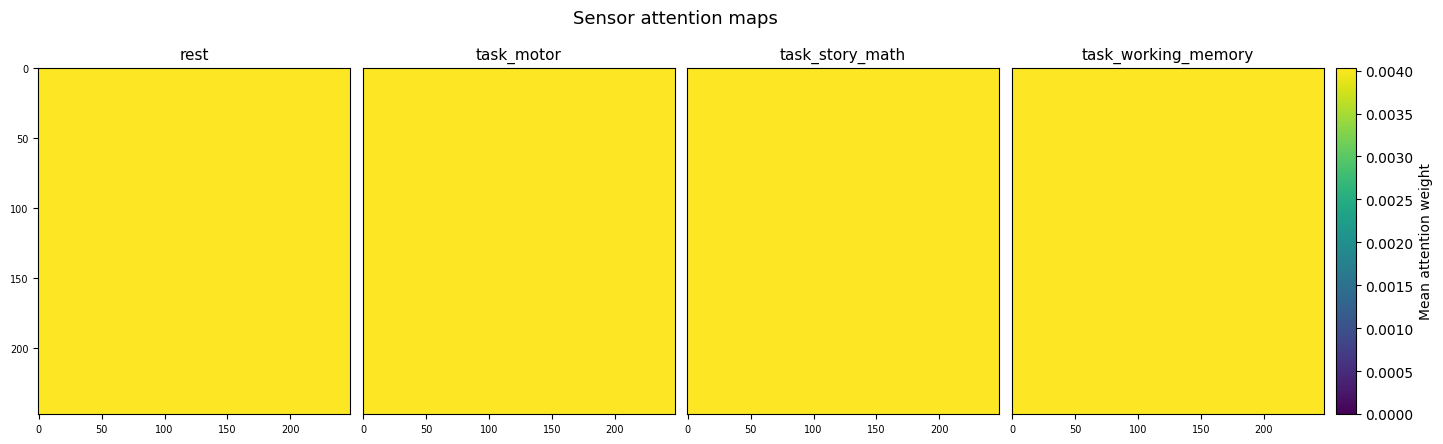

Saved → sensor_attention_maps_first.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
from dataset import CLASS_NAMES

# ── 1. Collect attention weights per class ────────────────────────────────────
class_attns = defaultdict(list)

model = best_model

model.eval()
with torch.no_grad():
    for batch in cross_test_loader:
        x_batch = batch[0].to(DEVICE)
        y_batch = batch[1].to(DEVICE)

        #_ = model(x_batch)
        attn = model.get_attention_weights(x_batch)          # (B, H, N, N)
        attn_avg = attn.mean(dim=1).cpu().numpy()     # (B, N, N) — average over heads

        for i in range(attn_avg.shape[0]):
            label = CLASS_NAMES[y_batch[i].item()]
            class_attns[label].append(attn_avg[i])

# ── 2. Compute per-class mean maps ────────────────────────────────────────────
sorted_labels  = sorted(class_attns.keys())
mean_maps      = {label: np.stack(class_attns[label]).mean(axis=0)
                  for label in sorted_labels}

# All-class average
all_maps = np.concatenate(list(class_attns.values()), axis=0)
# mean_maps["all"] = all_maps.mean(axis=0)
# sorted_labels = ["all"] + sorted_labels  # prepend so it appears first

# Shared colour range across all classes so maps are directly comparable
vmin = min(m.min() for m in mean_maps.values())
vmax = max(m.max() for m in mean_maps.values())

# ── 3. Plot ───────────────────────────────────────────────────────────────────
n_classes   = len(sorted_labels)
class_names = {i: f"{i}" for i in sorted_labels}
class_names["all"] = "all"

fig = plt.figure(figsize=(4 * n_classes + 1, 4.5))
gs  = gridspec.GridSpec(
    1, n_classes + 1,
    width_ratios=[4] * n_classes + [0.25],   # last column = colourbar
    wspace=0.05,
)

axes = [fig.add_subplot(gs[0, j]) for j in range(n_classes)]
cax  =  fig.add_subplot(gs[0, n_classes])

for ax, label in zip(axes, sorted_labels):
    im = ax.imshow(
        mean_maps[label],
        cmap="viridis",
        vmin=0,
        vmax=vmax,
        aspect="auto",
        interpolation="nearest",
    )
    ax.set_title(class_names[label], fontsize=11, pad=6)
    # ax.set_xlabel("Sensor", fontsize=8)
    if ax is axes[0]:
        # ax.set_ylabel("Sensor", fontsize=8)
        pass
    else:
        ax.set_yticks([])           # hide redundant y-ticks on subsequent panels

    # Optional: thin tick marks every 50 sensors
    ticks = np.arange(0, mean_maps[label].shape[0], 50)
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticks, fontsize=7)
    if ax is axes[0]:
        ax.set_yticks(ticks)
        ax.set_yticklabels(ticks, fontsize=7)

fig.colorbar(im, cax=cax, label="Mean attention weight")
fig.suptitle("Sensor attention maps", fontsize=13, y=1.01)
plt.savefig("results/sensor_attention_maps_first.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → sensor_attention_maps_first.png")

In [ ]:
print(f"graph_gate: {model.graph_gate.item():.3f}  "
      f"sigmoid: {torch.sigmoid(model.graph_gate).item():.3f}")

graph_gate: -2.795  sigmoid: 0.058


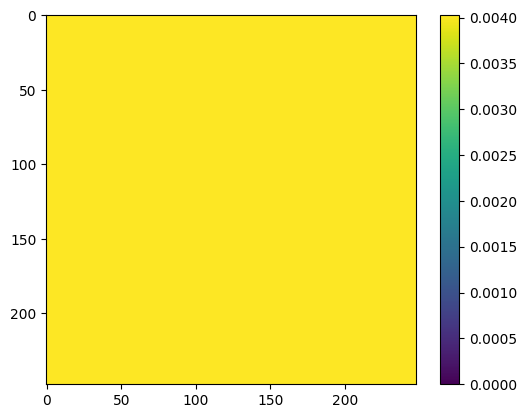

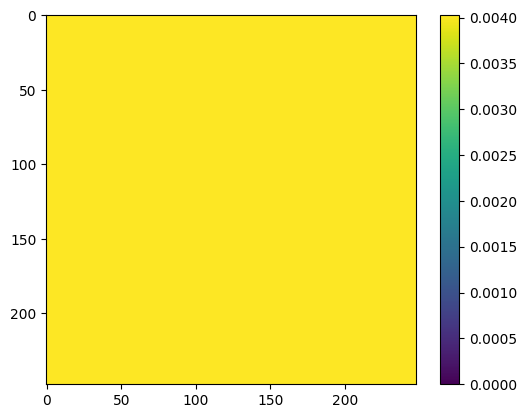

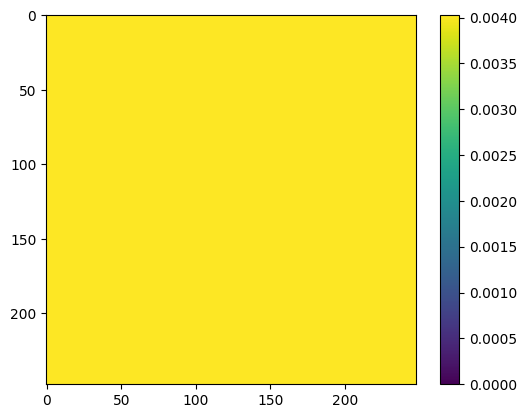

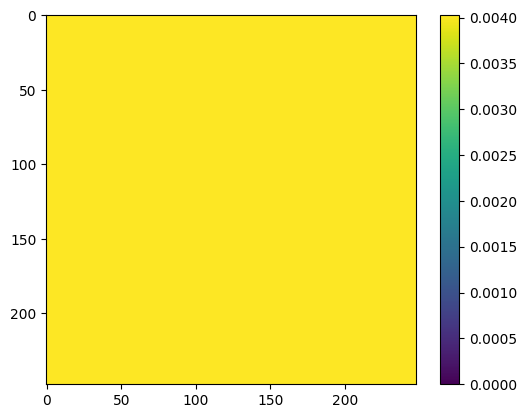

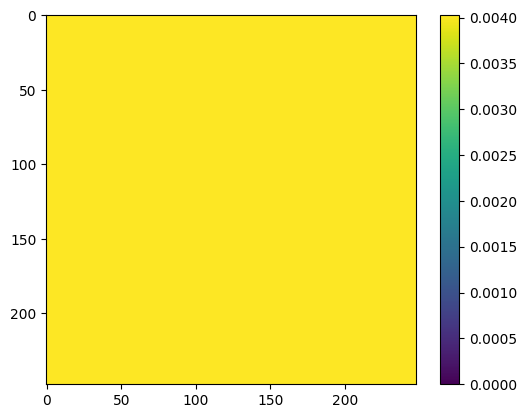

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt

class_attns = defaultdict(list)

model.eval()
with torch.no_grad():
    #for x_batch, y_batch in cross_test_loader:
    for batch in cross_test_loader:
        x_batch = batch[0].to(DEVICE)
        y_batch = batch[1].to(DEVICE)
        _ = model(x_batch)
        attn = model.get_attention_weights(x_batch)          # (B, H, N, N)
        attn_avg = attn.mean(dim=(1,)).cpu().numpy()  # (B, N, N) — keep batch dim
        for i in range(attn_avg.shape[0]):
            label = y_batch[i].item()
            class_attns[label].append(attn_avg[i])

# Average per class
for label, maps in class_attns.items():
    mean_map = np.stack(maps).mean(axis=0)           # (N, N)
    plt.imshow(mean_map, cmap="viridis", vmin=0, vmax=mean_map.max())
    plt.colorbar()
    plt.show()

# All classes combined
all_maps = np.concatenate([np.stack(maps) for maps in class_attns.values()], axis=0)
mean_map = all_maps.mean(axis=0)
plt.imshow(mean_map, cmap="viridis", vmin=0, vmax=mean_map.max())
plt.colorbar()
plt.show()